Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(font_scale=1.1)

Load Dataset

In [2]:
df = pd.read_csv("heart.csv")
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [3]:
print("Shape: ", df.shape)

Shape:  (918, 12)


In [4]:
print("Info: ", df.info())

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
Info:  None


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


Define target and feature type

In [6]:
target_col = "HeartDisease"
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print(target_col)
print(numeric_cols)
print(categorical_cols)

HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


Check missing values count per columm

In [7]:
df.isna()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
913,False,False,False,False,False,False,False,False,False,False,False,False
914,False,False,False,False,False,False,False,False,False,False,False,False
915,False,False,False,False,False,False,False,False,False,False,False,False
916,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

look at some basic value ranges

In [9]:
df[numeric_cols].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [10]:
df[categorical_cols]

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [11]:
for i in categorical_cols:
    # print(i, df[i].unique())
    print(f"{i} == {df[i].unique()}")

Sex == <StringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType == <StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG == <StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina == <StringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope == <StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


In [12]:
# df["Age"].hist(bins=50, figsize=(10, 5))
# plt.xticks()

# plt.title("Age Distribution")
# plt.suptitle("Heart Disease Dataset Analysis")
# plt.xlabel("Age")
# plt.ylabel("Frequency")
# plt.tight_layout()
# plt.show()

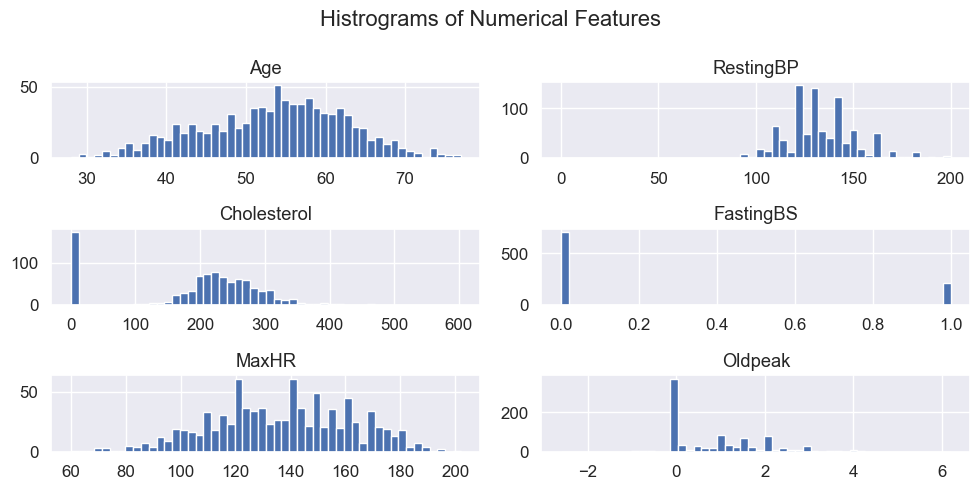

In [13]:
df[numeric_cols].hist(bins=50, figsize=(10, 5))
plt.suptitle("Histrograms of Numerical Features")
plt.tight_layout()
plt.show()

HeartDisease,0,1
Age,,
31,1,1
32,3,2
33,1,1
34,5,2
35,7,4
36,4,2
37,10,1
38,5,11
39,13,2


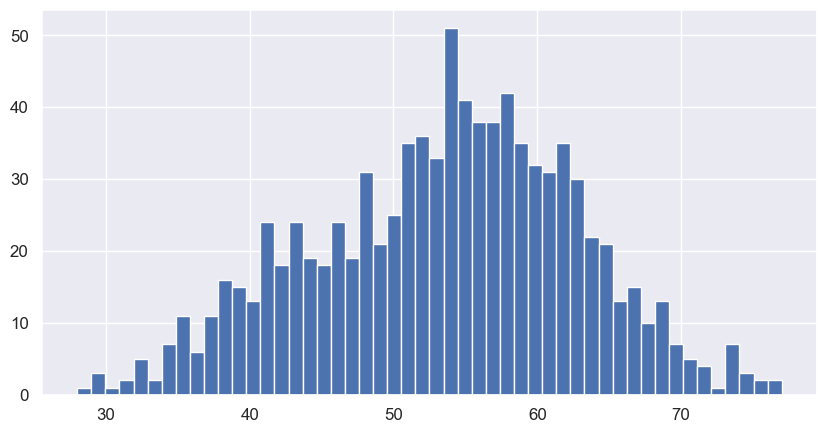

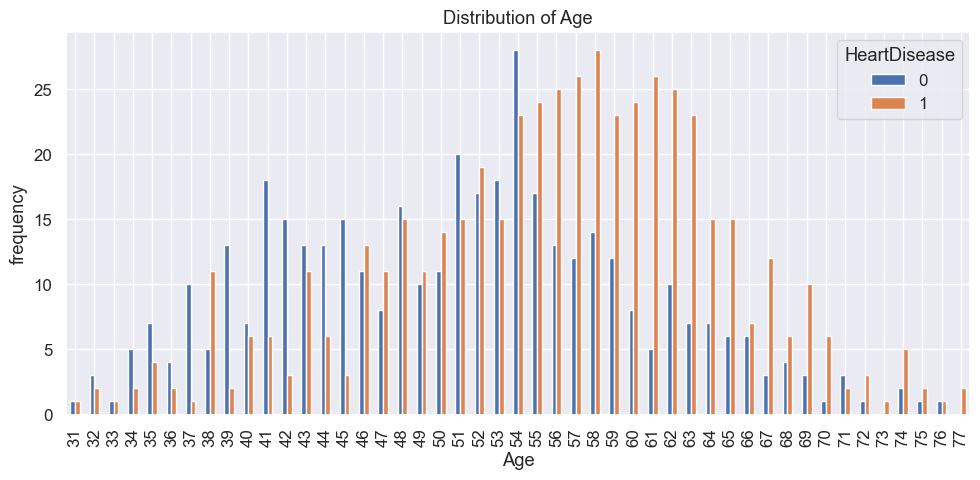

HeartDisease,0,1
RestingBP,,
0,0,1
92,0,1
95,0,6
96,0,1
100,8,7
...,...,...
180,6,6
185,0,1
190,1,1


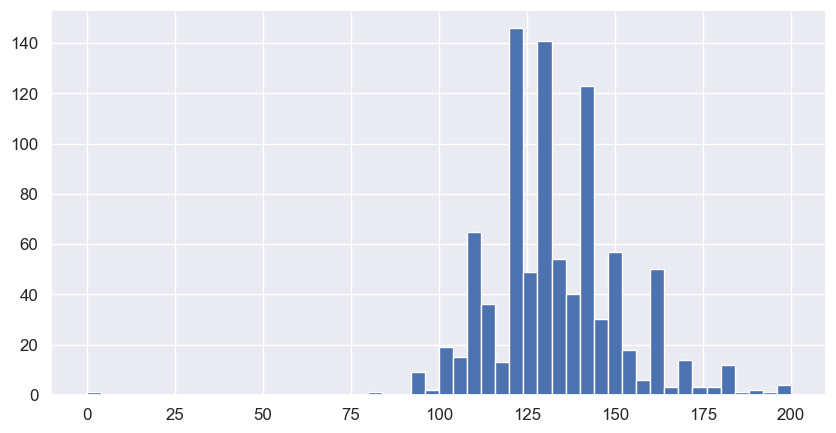

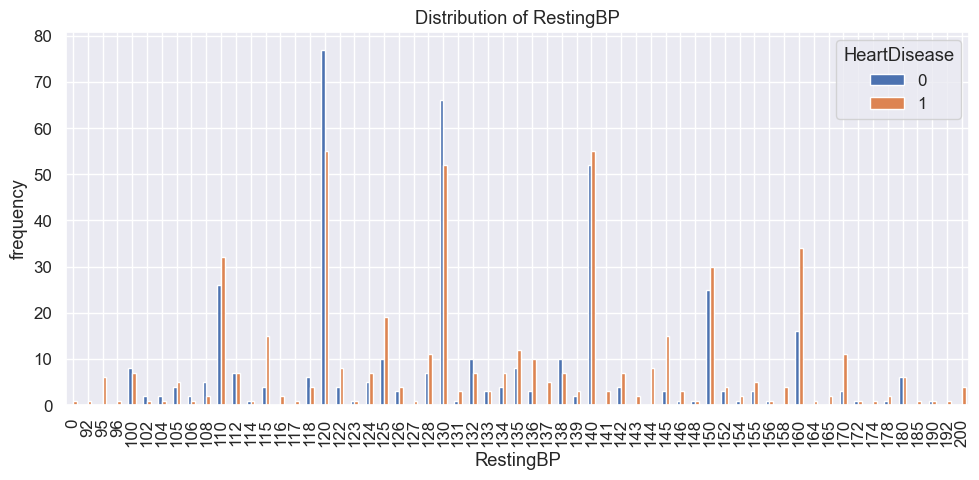

HeartDisease,0,1
Cholesterol,,
0,20,152
100,1,1
110,0,1
113,0,1
117,0,1
...,...,...
466,0,1
491,0,1
518,0,1


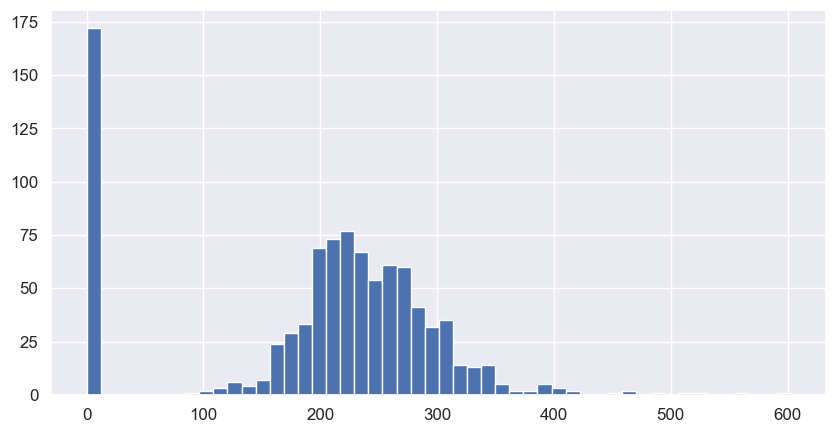

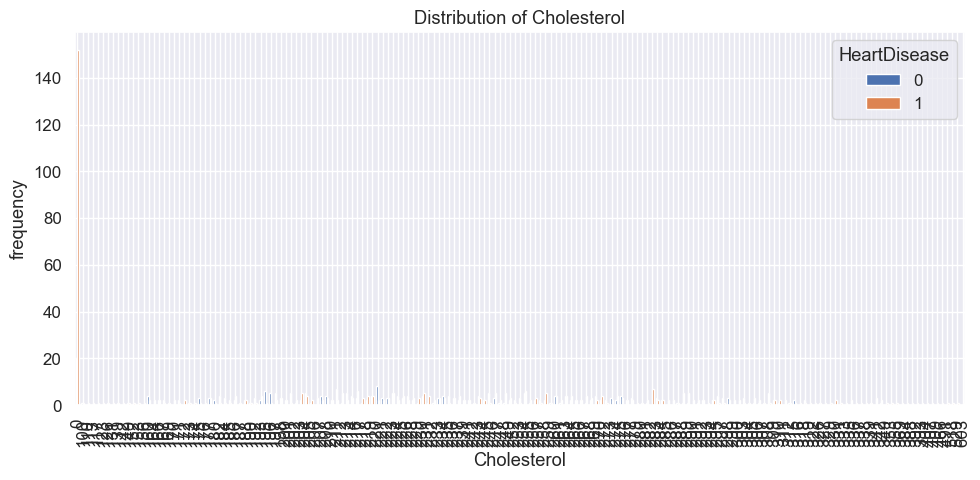

HeartDisease,0,1
FastingBS,,
0,366,338
1,44,170


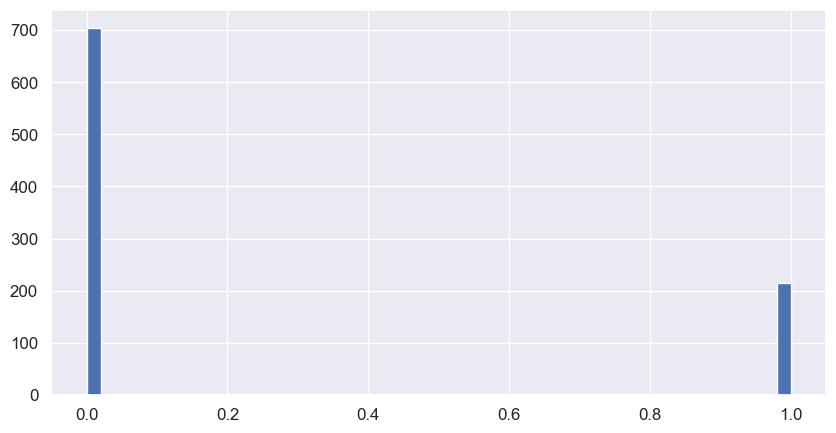

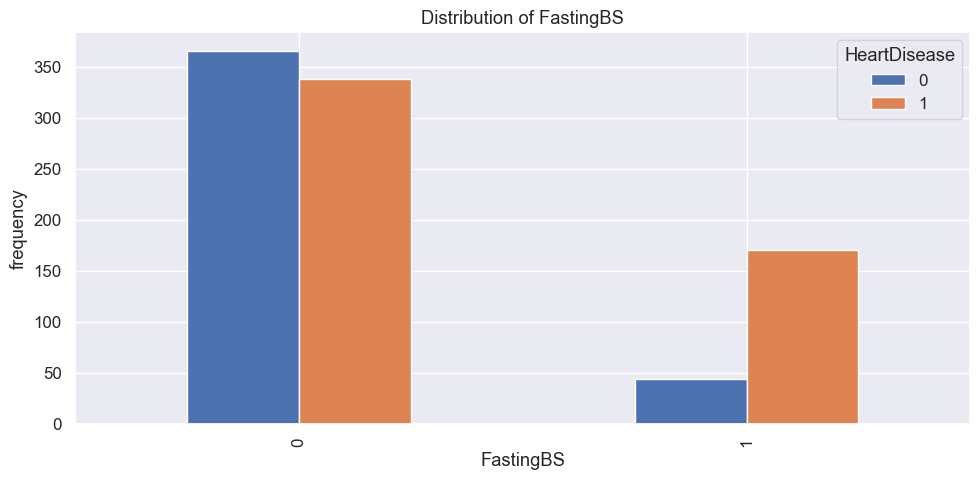

HeartDisease,0,1
MaxHR,,
60,0,1
63,0,1
67,0,1
70,0,1
71,0,1
...,...,...
177,0,1
180,8,2
181,1,1


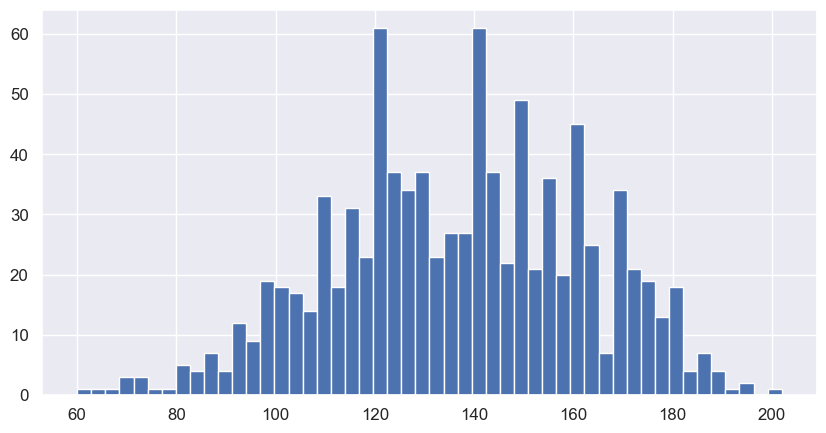

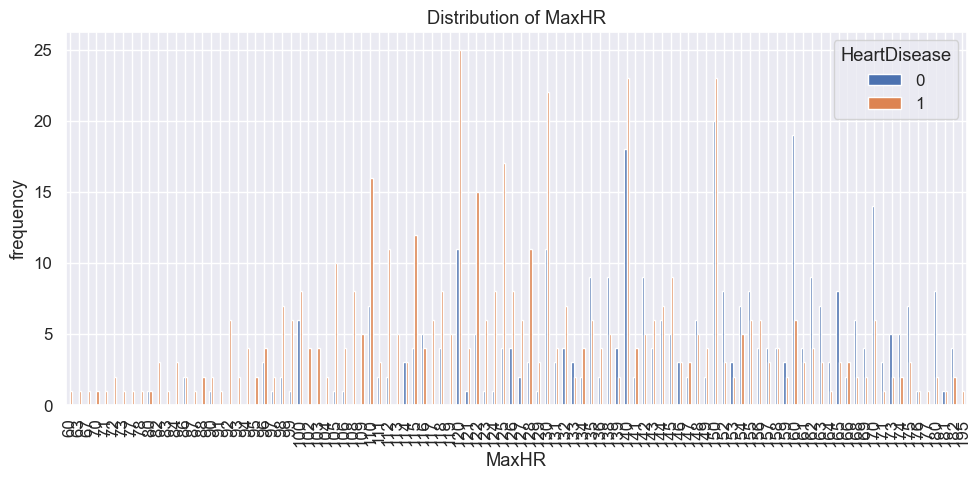

HeartDisease,0,1
Oldpeak,,
-2.6,0,1
-2.0,0,1
-1.5,0,1
-1.0,0,2
-0.9,0,1
-0.8,0,1
-0.7,0,1
-0.5,1,1
0.0,244,124


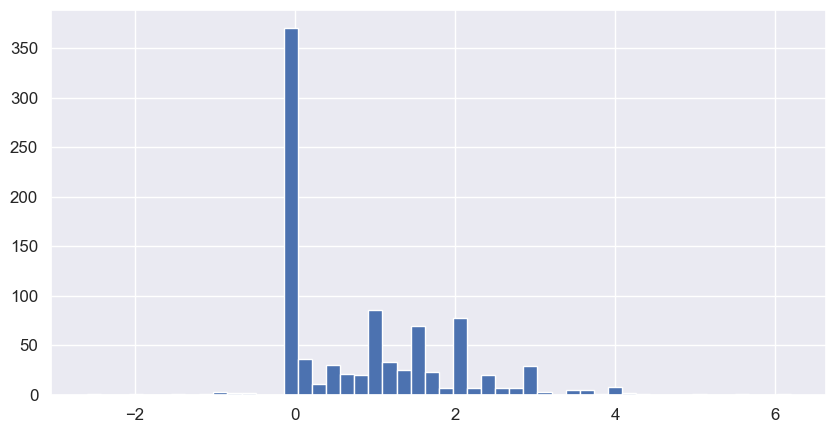

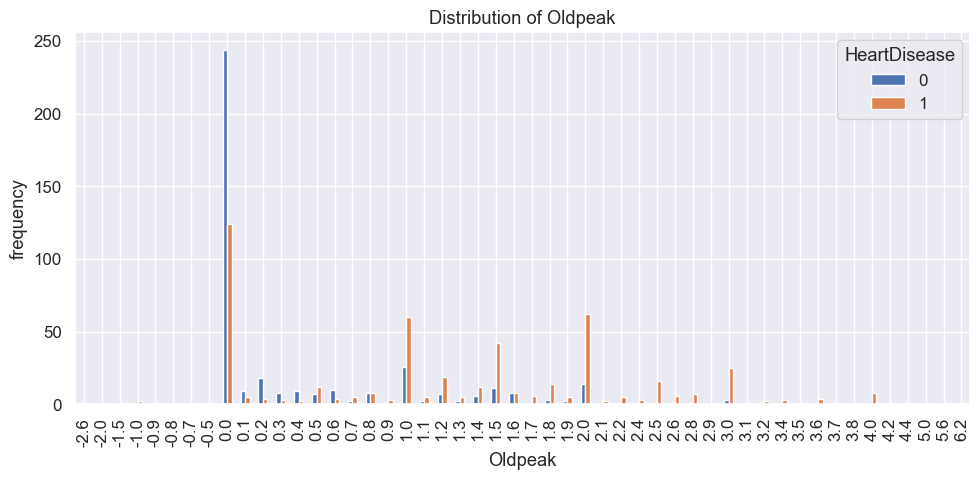

In [14]:
for i in numeric_cols:
    ct = pd.crosstab(df[i], df[target_col])
    ct = ct[ct[1] > 0]
    display(ct)
    df[i].hist(bins=50, figsize=(10, 5))
    # ct.hist()
    ct.plot(kind="bar", figsize=(10, 5))
    # plt.suptitle(f"HeartDisease Dataset Analysis")
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("frequency")
    # plt.xticks(rotation=90)
    plt.tight_layout()
    # print(ct)
    plt.show()

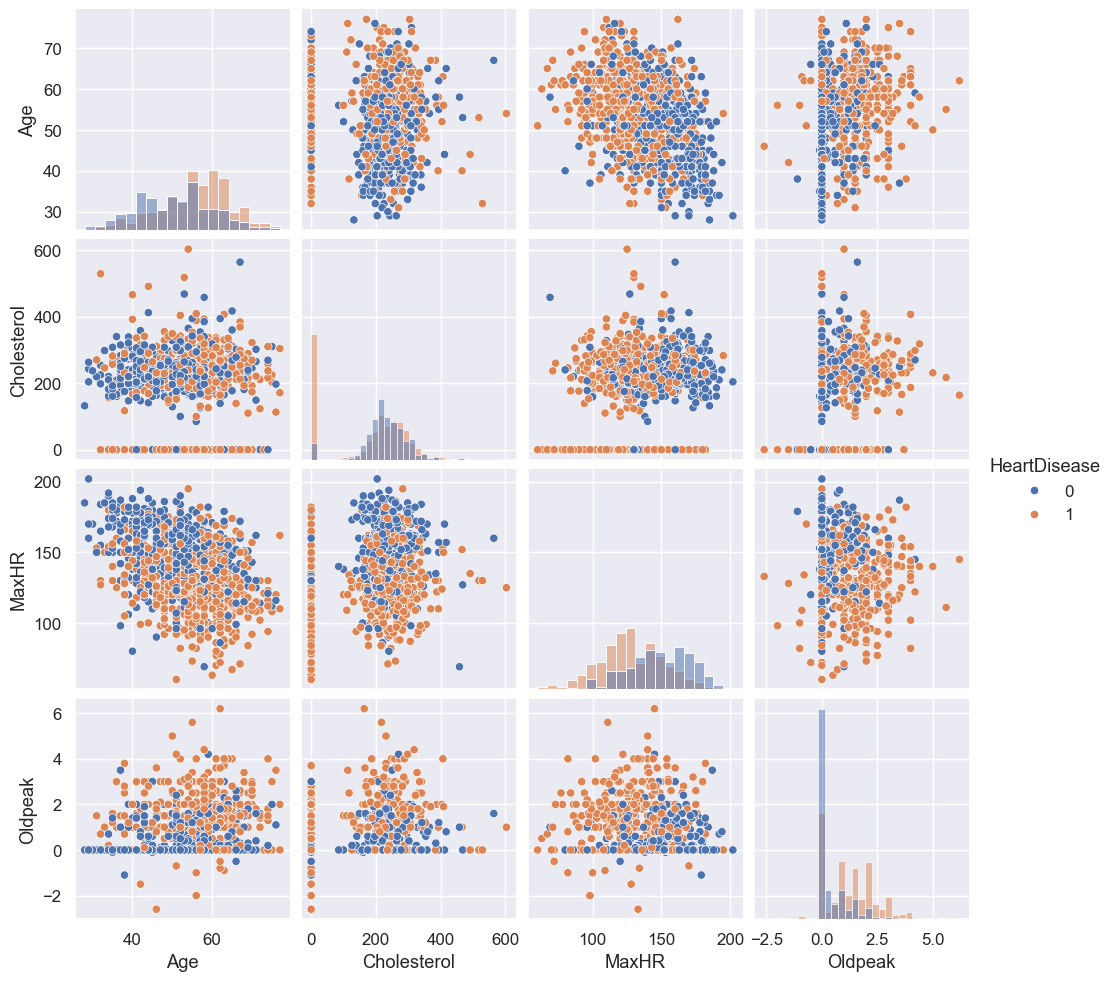

In [15]:
sns.pairplot(
    df[["Age", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease"]],
    hue="HeartDisease",
    diag_kind="hist",
)
plt.show()


Proportion of HeartDisease within Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


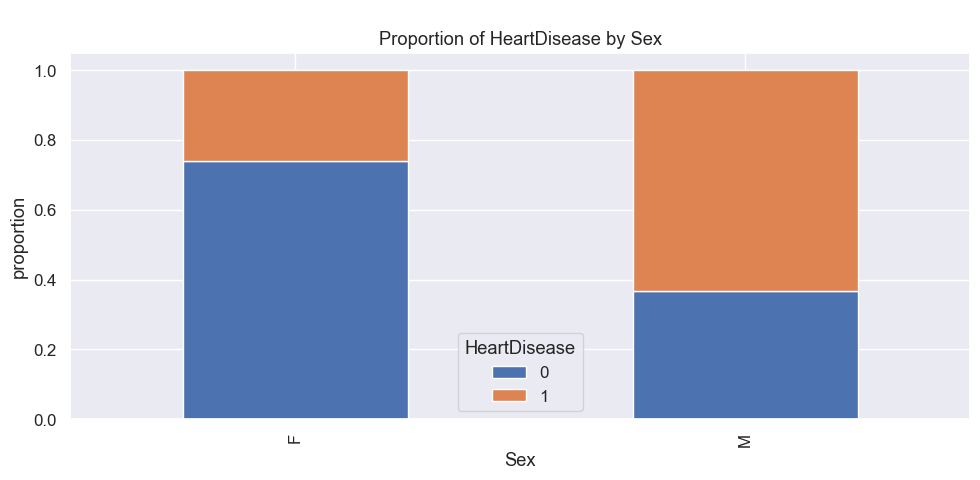


Proportion of HeartDisease within ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


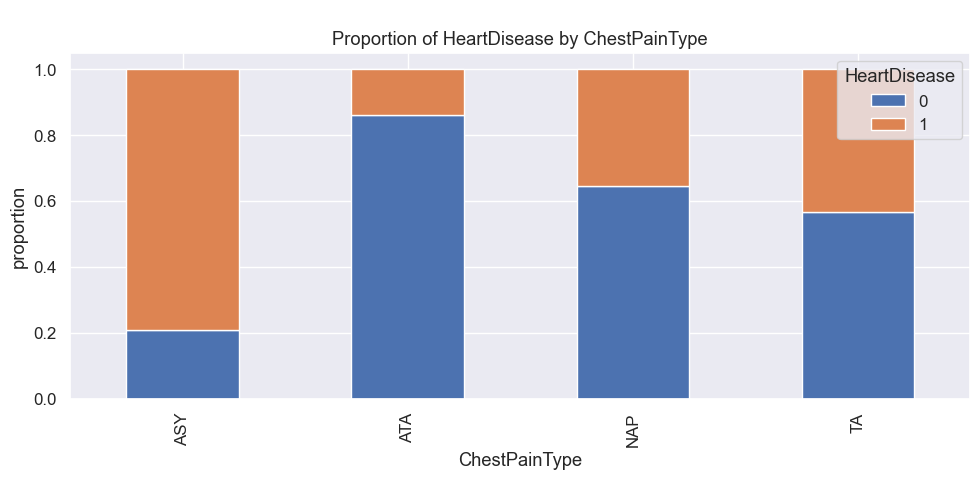


Proportion of HeartDisease within RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


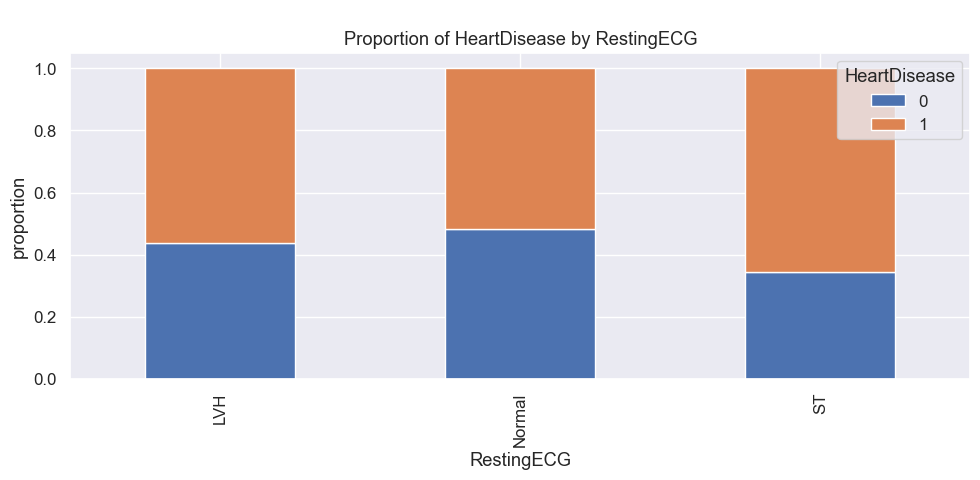


Proportion of HeartDisease within ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


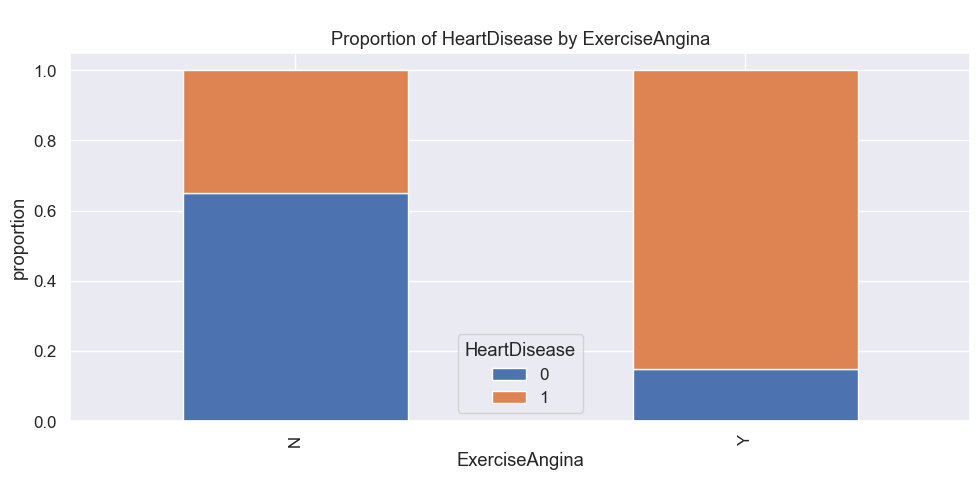


Proportion of HeartDisease within ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


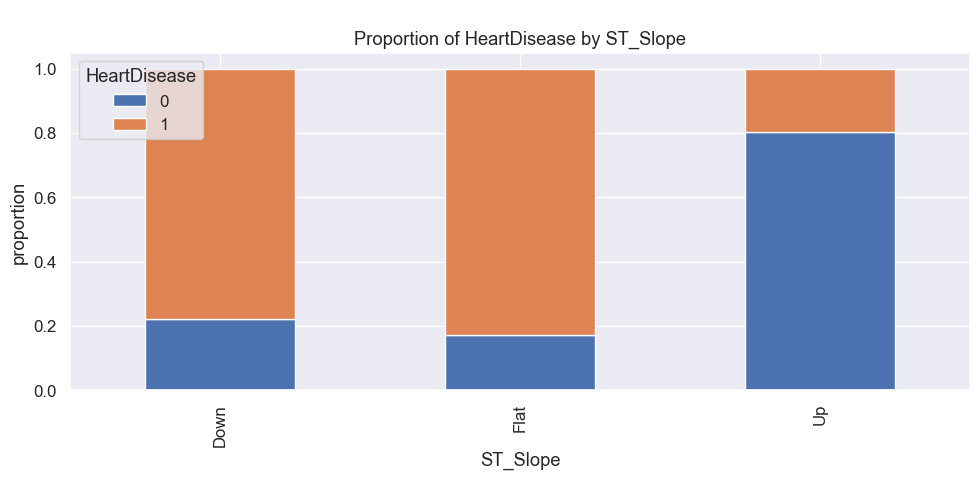

In [16]:
for i in categorical_cols:
    ct = pd.crosstab(df[i], df[target_col], normalize="index")
    print(f"\nProportion of HeartDisease within {i}")
    display(ct)

    ct.plot(kind="bar", stacked=True, figsize=(10, 5))

    plt.title(f"\nProportion of HeartDisease by {i}")
    plt.ylabel("proportion")
    plt.xticks()
    plt.tight_layout()
    plt.show()